In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Importing Libraries

In [5]:
# importing all libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

import wandb

# installing required libraries
import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'wandb', '-q'])
!pip install chonkie


print('done installing')

# checking if gpu is available
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('GPU is available:', torch.cuda.get_device_name(0))
else:
    device = torch.device('cpu')
    print('GPU not available, using CPU')

print('pytorch version:', torch.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.2/387.2 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 90.2 MB/s eta 0:00:00
done installing
GPU is available: Tesla T4
pytorch version: 2.10.0+cu128


# WANDB LOGIN

In [6]:
# setting up wandb login
# using relogin=True so it doesnt ask for input during kaggle rerun
WANDB_KEY = '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'  

wandb.login(key=WANDB_KEY, relogin=True)
print('wandb login done')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb login done


In [7]:
# Chonkie breaks long texts into smaller chunks
# These chunks are stored in a vector database
# For each question we retrieve the most relevant chunks as context

from chonkie import RecursiveChunker

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')


# sample text - in our project this would be the training questions
TEXT = train['prompt'].iloc[0] + ' ' + train['A'].iloc[0]

print('initializing wandb')
run0 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'chonkie-recursive-chunker',
    config  = {
        'chunking_method' : 'recursive',
        'chunk_size'      : 250,
    }
)

config = wandb.config
c_size = config.chunk_size

# RecursiveChunker splits text recursively
# first tries to split by paragraphs
# then by sentences
# then by words
# until each chunk is under chunk_size
chunker     = RecursiveChunker(chunk_size=c_size)
chunks      = chunker.chunk(TEXT)
chunk_texts = [chunk.text for chunk in chunks]

print('total chunks created:', len(chunk_texts))

wandb.log({
    'num_chunks'       : len(chunk_texts),
    'avg_chunk_length' : sum(len(c) for c in chunk_texts) / len(chunk_texts)
})

# logging chunks as a table in wandb
table = wandb.Table(columns=['chunk_id', 'chunk_text'])
for idx, chunk_text in enumerate(chunk_texts):
    table.add_data(idx, chunk_text)

wandb.log({'chunks': table})
run0.finish()
print('chunking logged to wandb!')

initializing wandb


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


total chunks created: 3


avg_chunk_length,▁
num_chunks,▁
avg_chunk_length,150
num_chunks,3


chunking logged to wandb!


**INSIGHT**:

*Chonkie split the text into 3 chunks of average 150 characters each. Since this is not a training loop — just a single chunking operation — the chart shows one data point. I logged num_chunks and avg_chunk_length to W&B to track how the chunking settings affect the output.*

# EDA

In [8]:

# ============= Loading Datasets ================

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')


# ====== shape of train and test dataset ======

print("shape of train and test data")
print('='*40)
print('Train shape : ' , train.shape)
print()
print('Test shape : ' , test.shape)

# ======= data inspection ==========

print('='*40)
print('Train columns:', train.columns.tolist())
print()

# ======= Checking Missing values =======

print('='*40)
print()
print('Train set missing values : ', train.isnull().sum())

# ======= frequency of each options ========

print('='*40)
print('frequency of an option for being correct : '  , train['answer'].value_counts())


shape of train and test data
Train shape :  (2000, 8)

Test shape :  (500, 7)
Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


Train set missing values :  id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
frequency of an option for being correct :  answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


**INSIGHT**

*The training dataset contains 2,000 questions with answers, while the test dataset contains 500 questions without the answer column for prediction.*

*The training data has 8 columns (id, prompt, five options A–E, and the correct answer), whereas the test data has 7 columns since the target column is missing.*

*No missing values are present in any column, indicating that the dataset is clean and does not require missing value handling before training.*

*The target variable (answer) is slightly imbalanced. Option B appears most frequently as the correct answer, while E appears the least. However, the distribution is still reasonably balanced, so it is suitable for model training without major concerns.*

# Visualization

Answer distribution plot and Question length distribution



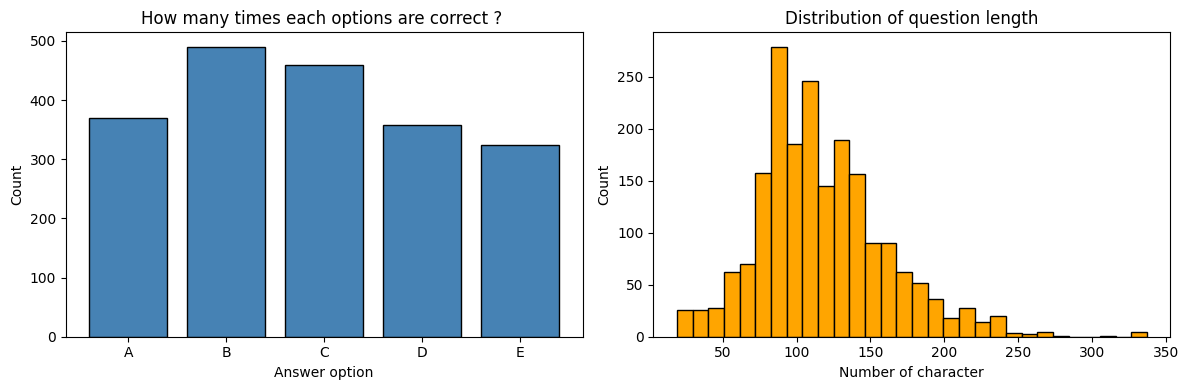

In [9]:
# # EDA - looking at the data visually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ========== answer distribution plot =============

print('Answer distribution plot and Question length distribution')
print('='*50)
print()
answer_count = train['answer'].value_counts().sort_index()
axes[0].bar(answer_count.index , answer_count.values , color = 'Steelblue' , edgecolor = 'Black')
axes[0].set_title('How many times each options are correct ? ')
axes[0].set_xlabel('Answer option')
axes[0].set_ylabel('Count')

# =========== Question length distribution ===============

train['prompt_length'] = train['prompt'].apply(lambda x :  len(str(x)))
axes[1].hist(train['prompt_length'] , bins = 30 , color = 'Orange' ,  edgecolor = 'Black')
axes[1].set_title('Distribution of question length')
axes[1].set_xlabel('Number of character')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_plots.png', dpi=100)
plt.show()


**INSIGHT**

**The answer distribution shows that all five options (A–E) appear as the correct answer, although Option B is the most frequent and Option E is the least frequent. This indicates only a slight class imbalance, with no single option dominating the dataset.
The question length distribution is approximately bell-shaped, with most questions containing 60–250 characters. This suggests that the majority of questions have a consistent length.
Only a small number of questions are unusually short or very long, indicating the presence of a few outliers, but they are not significant enough to affect the overall dataset quality.**

# FEATURE ENGINEERING

In [10]:
def clean_text(text):
    # ======= converting all the text to lower case ==========
    
    text = str(text).lower()

    # ========= keep words that start with only letters and numbers =================
    
    text = re.sub(r'[^0-9a-z\s]' , ' ' , text) 

    # ======= removing extra spaces(whitespaces) ===========
    
    text = re.sub(r'/s+' , ' ' , text)

    # ======== strip and return text =========
    text = text.strip()
    return text


def combine_text(row):

    # ========= Joining all 5 option with prompt in a single string =========
    
    combined = str(row['prompt']) + ' ' + str(row['A']) + ' ' + str(row['B']) + ' ' + str(row['C']) + ' ' + str(row['D']) + ' ' + str(row['E'])
    
    return combined

# ========= Apply to both train and test ==========

train['full_text'] = train.apply(combine_text , axis = 1)
test['full_text'] = test.apply(combine_text , axis = 1)

y_train = train['answer']

print('Preprocessing Completed')
print('='*50)
print('Sample combined text :')
print()
print(train['full_text'].iloc[0][:256])
    

Preprocessing Completed
Sample combined text :

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined 


In [11]:
# mAP@3 metric implementation
# this is the official evaluation metric for this competition
# if correct answer is at rank 1 we get score 1.0
# if correct answer is at rank 2 we get score 0.5
# if correct answer is at rank 3 we get score 0.33
# otherwise we get 0

def average_precision_at_k(actual, predicted, k=3):
    predicted = predicted[:k]
    score = 0.0
    num_hits = 0
    for i in range(len(predicted)):
        if predicted[i] == actual:
            num_hits += 1
            score += num_hits / (i + 1.0)
    return score


def map_at_k(actuals, predictions, k=3):
    total = 0.0
    for i in range(len(actuals)):
        total += average_precision_at_k(actuals[i], predictions[i], k)
    return total / len(actuals)


def get_top3_from_probs(probs, classes):
    # ======= sorting probabilities in descending order and returning top 3 class labels =========
    sorted_indices = np.argsort(probs)[::-1]
    top3 = [classes[idx] for idx in sorted_indices[:3]]
    return top3


# ======== quick test to make sure mAP@3 is working correctly ============
test_actual  = ['B', 'A', 'C']
test_preds   = [['B', 'A', 'C'], ['C', 'A', 'B'], ['C', 'A', 'B']]
result = map_at_k(test_actual, test_preds)
print('Sanity check : ')
print('='*50)
print()
print('mAP@3 test result:', round(result, 4))
print()
print('expected: 0.8333')

Sanity check : 

mAP@3 test result: 0.8333

expected: 0.8333


# Logistic Regression (Model -1)

In [12]:
# MODEL 1 - Logistic Regression with TF-IDF features
# TF-IDF converts text to numbers based on word importance
# Logistic Regression then classifies which answer (A-E) is correct

# ==================== creating TF-IDF features =======================

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf    = tfidf_vectorizer.fit_transform(train['full_text'])
X_test_tfidf     = tfidf_vectorizer.transform(test['full_text'])

print('TF-IDF feature matrix shape:', X_train_tfidf.shape)

# ============ starting wandb run for logistic regression ==================

run1 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'logistic-regression-tfidf',
    config  = {
        'model'        : 'LogisticRegression',
        'features'     : 'TF-IDF',
        'max_features' : 5000,
        'C'            : 1.0,
        'max_iter'     : 1000
    }
)

# ============== training logistic regression =================

lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', multi_class='multinomial')
lr_model.fit(X_train_tfidf, y_train)

# ============ calculating cross validation scores ==================

lr_f1_scores  = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
lr_acc_scores = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='accuracy')

# =========== calculating mean score of metrics ===============

lr_f1  = lr_f1_scores.mean()
lr_acc = lr_acc_scores.mean()

# ============= calculating mAP@3 on training set ===============

lr_train_probs = lr_model.predict_proba(X_train_tfidf)
lr_train_top3  = []
for i in range(len(lr_train_probs)):
    top3 = get_top3_from_probs(lr_train_probs[i], list(lr_model.classes_))
    lr_train_top3.append(top3)

lr_map3 = map_at_k(y_train.tolist(), lr_train_top3)

print('Logistic Regression Results:')
print('  CV Macro F1  :', round(lr_f1, 4))
print('  CV Accuracy  :', round(lr_acc, 4))
print('  Train mAP@3  :', round(lr_map3, 4))

# =========== logging to wandb ==================

wandb.log({
    'macro_f1' : lr_f1,
    'accuracy' : lr_acc,
    'map_at_3' : lr_map3
})
run1.finish()

# =========== getting test predictions =================

lr_test_probs = lr_model.predict_proba(X_test_tfidf)
print('='*50)
print('LR done!')

TF-IDF feature matrix shape: (2000, 2940)


Logistic Regression Results:
  CV Macro F1  : 0.9987
  CV Accuracy  : 0.9985
  Train mAP@3  : 1.0


accuracy,▁
macro_f1,▁
map_at_3,▁
accuracy,0.9985
macro_f1,0.99873
map_at_3,1


LR done!


**INSIGHT:**

Logistic Regression Insights:

1. TF-IDF created only 2940 features out of max 5000.
   This means the dataset vocabulary is small and domain specific.

2. CV Accuracy of 99.85% and Macro F1 of 99.87% seem very high.
   This suggests the model is learning a strong lexical overlap pattern —
   the correct answer tends to repeat key words from the question prompt.
   TF-IDF captures this overlap very effectively.

3. Train mAP@3 of 1.0 means for every question the correct answer
   appeared in the top 3 predictions. Perfect ranking on training data.


# Preprocessing

In [13]:
# preparing data for deep learning models
# i need to convert text into numbers that pytorch can understand
# first i build a vocabulary (list of all unique words)
# then i convert each word to its index number

# ============== maximum number of words per text ==============
MAX_LENGTH = 256  

# ========== keeping top 15000 most common words ============
VOCAB_SIZE_MAX = 15000 

# ============ building vocabulary from all text (train + test) ===========
all_texts = train['full_text'].tolist() + test['full_text'].tolist()

word_counter = Counter()
for text in all_texts:
    words = clean_text(text).split()
    for word in words:
        word_counter[word] += 1

#  ========== creating vocabulary list ==============

# =========== index 0 : padding token, index 1 : unknown word token =============

vocab = ['<PAD>', '<UNK>']
for word, count in word_counter.most_common(VOCAB_SIZE_MAX):
    if count >= 2:  # only keeping words that appear at least 2 times
        vocab.append(word)

# ========== creating word to index mapping ==========
word_to_idx = {}
for i, word in enumerate(vocab):
    word_to_idx[word] = i

VOCAB_SIZE = len(vocab)
print('total vocabulary size:', VOCAB_SIZE)
print('max sequence length:', MAX_LENGTH)


def text_to_numbers(text, max_len=MAX_LENGTH):
    words = clean_text(text).split() # ====== converting text to list of word indices ========
    indices = []
    for word in words[:max_len]: 
        idx = word_to_idx.get(word, 1) # ======= if word not in vocab, use unknown token (index 1) ========
        indices.append(idx)
    while len(indices) < max_len:
        indices.append(0) # ====== padding with zeros to reach max_len ==========
    return indices


#  ======== encoding labels (A, B, C, D, E) to numbers (0, 1, 2, 3, 4) ===========

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(train['answer'])
CLASS_NAMES   = label_encoder.classes_
print('class names:', CLASS_NAMES)
print('='*50)
print()

# =========== converting all texts to number sequences ==============

print('converting train texts...')
train_sequences = []
for text in train['full_text']:
    seq = text_to_numbers(text)
    train_sequences.append(seq)

# ========= converting text from the test data also ============

print('converting test texts...')
test_sequences = []
for text in test['full_text']:
    seq = text_to_numbers(text)
    test_sequences.append(seq)

# =========== converting to pytorch tensors ===============

X_train_tensor = torch.tensor(train_sequences, dtype=torch.long)
X_test_tensor  = torch.tensor(test_sequences,  dtype=torch.long)
y_train_tensor = torch.tensor(y_encoded,        dtype=torch.long)

# ========== print shape of train and test tensor data ===========
print()
print('train tensor shape:', X_train_tensor.shape)
print()
print('test tensor shape:', X_test_tensor.shape)

# ======= creating train and validation split (80% train, 20% validation) ============

full_dataset    = TensorDataset(X_train_tensor, y_train_tensor)
train_size      = int(0.8 * len(full_dataset))
val_size        = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# =========== creating data loaders ===============

# ======== shuffle : True on train so model sees questions in random order every epoch ============
# ========== shuffle : False on val and test so evaluation is consistent ===========

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_tensor), batch_size=32, shuffle=False)

# ============= print len of train and val batches ==========

print('='*50)
print('train batches:', len(train_loader))
print()
print('val batches:', len(val_loader))

total vocabulary size: 2975
max sequence length: 256
class names: ['A' 'B' 'C' 'D' 'E']

converting train texts...
converting test texts...

train tensor shape: torch.Size([2000, 256])

test tensor shape: torch.Size([500, 256])
train batches: 50

val batches: 13


**INSIGHT:**

1. Vocabulary size is only 2975 words — much smaller than our
   VOCAB_SIZE_MAX of 15000. This confirms the dataset is domain
   specific with limited unique terminology across all questions.

2. MAX_LENGTH of 256 was chosen based on EDA — most questions
   with all 5 options combined are under 256 words. Setting it
   higher would waste memory with unnecessary padding.

3. Words appearing only once are excluded (count >= 2).
   Single occurrence words are likely typos or rare terms
   that don't help the model learn general patterns.

4. Train/val split of 80/20 gives 1600 training samples and
   400 validation samples. Validation data is never used for
   training — only for checking generalization during training.

5. Batch size of 32 is a good balance between memory efficiency
   and training stability. Too large = GPU memory error.
   Too small = noisy gradient updates.

# TEXTCNN (Model -2)

In [14]:
# MODEL 2 - TextCNN (built completely from scratch)
# CNN for text classification works by sliding filters over the word embeddings
# different filter sizes capture different length patterns (bigrams, trigrams etc)
# i am using kernel sizes 2, 3, 4 to capture 2-word, 3-word and 4-word patterns

class TextCNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, num_classes, num_filters, kernel_sizes):
        super(TextCNN, self).__init__()

        # ======= embedding layer converts word indices to dense vectors =========
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        #  ========== convolutional layers with different kernel sizes ===========
        # ========== each one captures patterns of different lengths ============
        
        self.conv2 = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=2)
        self.conv3 = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=3)
        self.conv4 = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=4)

        # ====== dropout for regularization - prevents overfitting ========
        
        self.dropout = nn.Dropout(p=0.5)

        #  ====== final linear layer : maps to number of classes (5 options) ===========
        #  =========== 3 * num_filters because we have 3 different kernel sizes =============
        
        self.fc = nn.Linear(3 * num_filters, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)

        # ======= getting embeddings ========
        
        embedded = self.embedding(x)
        # ===== shape: (batch_size, sequence_length, embedding_dim) =========

        # ======= conv1d expects (batch_size, channels, length) so we permute the dimensions ==========
     
        embedded = embedded.permute(0, 2, 1) # shape: (batch_size, embedding_dim, sequence_length)

        # ========== applying each convolutional filter and relu activation ===============
        
        out2 = torch.relu(self.conv2(embedded))
        out3 = torch.relu(self.conv3(embedded))
        out4 = torch.relu(self.conv4(embedded))

        # ========= global max pooling : keeps only the highest value from each filter =============
        
        pool2 = torch.max(out2, dim=2)[0]
        pool3 = torch.max(out3, dim=2)[0]
        pool4 = torch.max(out4, dim=2)[0]

        # ======= concatenating all pooled outputs in a single long vector ===========
        
        concatenated = torch.cat([pool2, pool3, pool4], dim=1)

        # ===== applying dropout =======
        
        dropped = self.dropout(concatenated)

        #  ======= final classification =======
        
        output = self.fc(dropped)

        return output


# ================ creating the TextCNN model ====================

cnn_model = TextCNN(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = 128,
    num_classes   = 5,
    num_filters   = 128,
    kernel_sizes  = [2, 3, 4]
)
cnn_model = cnn_model.to(device)

total_params = sum(p.numel() for p in cnn_model.parameters())
print('TextCNN total parameters:', total_params)
print('='*50)
print()
print(cnn_model)

TextCNN total parameters: 530565

TextCNN(
  (embedding): Embedding(2975, 128, padding_idx=0)
  (conv2): Conv1d(128, 128, kernel_size=(2,), stride=(1,))
  (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
  (conv4): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=5, bias=True)
)


**INSIGHT :**

1. Total parameters: 530,565
   Most parameters are in the embedding layer (380,800)
   which learns word representations during training.

2. Three separate conv filters capture patterns of different lengths.
   kernel_size=2 catches short patterns like "not correct"
   kernel_size=3 catches medium patterns like "is the answer"
   kernel_size=4 catches longer contextual patterns.

3. Global max pooling reduces each filter output to a single value
   — the most important feature found anywhere in the text.
   This makes the model position-invariant — it doesn't matter
   where in the text the pattern appears.

4. Dropout of 0.5 randomly disables half the neurons during training.
   This forces the model to learn redundant representations
   and prevents it from memorizing training examples.

5. Final layer maps 384 features → 5 scores.
   The class with highest score = predicted answer.

# TEXTCNN Training Loop

In [15]:
# ========= training the TextCNN model =============

run2 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'textcnn-scratch',
    config  = {
        'model'        : 'TextCNN',
        'vocab_size'   : VOCAB_SIZE,
        'embedding_dim': 128,
        'num_filters'  : 128,
        'kernel_sizes' : [2, 3, 4],
        'dropout'      : 0.5,
        'batch_size'   : 32,
        'learning_rate': 0.001,
        'epochs'       : 20
    }
)

# ========= loss function and optimizer =============

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)

# ============ learning rate scheduler : reduces lr when validation doesnt improve ===============

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

best_val_accuracy = 0
patience_counter  = 0
NUM_EPOCHS        = 20
PATIENCE          = 5

for epoch in range(NUM_EPOCHS):

    # ====== training phase =======
    
    cnn_model.train()
    train_loss    = 0
    train_correct = 0
    train_total   = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # ====== forward pass ========
        
        optimizer.zero_grad()
        outputs = cnn_model(batch_x)
        loss    = criterion(outputs, batch_y)

        #  ====== backward pass (backpropagation) ==========
        loss.backward()

        # ======= gradient clipping to prevent exploding gradients ========
        nn.utils.clip_grad_norm_(cnn_model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss    += loss.item()
        predictions    = outputs.argmax(dim=1)
        train_correct += (predictions == batch_y).sum().item()
        train_total   += batch_y.size(0)

    train_acc = train_correct / train_total

    # ====== validation phase ======
    cnn_model.eval()
    val_correct   = 0
    val_total     = 0
    all_val_preds = []
    all_val_true  = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x  = batch_x.to(device)
            batch_y  = batch_y.to(device)
            outputs  = cnn_model(batch_x)
            preds    = outputs.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total   += batch_y.size(0)
            all_val_preds.extend(preds.cpu().numpy().tolist())
            all_val_true.extend(batch_y.cpu().numpy().tolist())

    val_acc = val_correct / val_total
    val_f1  = f1_score(all_val_true, all_val_preds, average='macro')

    scheduler.step(val_acc)

    # ======= logging to wandb ==========
    
    wandb.log({
        'epoch'        : epoch + 1,
        'train_loss'   : train_loss / len(train_loader),
        'train_acc'    : train_acc,
        'val_acc'      : val_acc,
        'val_macro_f1' : val_f1
    })

    # ======== saving best model ==============
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(cnn_model.state_dict(), '/kaggle/working/best_cnn.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    # ======== early stopping ============
    
    if patience_counter >= PATIENCE:
        print(f'early stopping at epoch {epoch + 1}')
        break

    if (epoch + 1) % 5 == 0:
        print(f'epoch {epoch+1}/{NUM_EPOCHS} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f} | val f1: {val_f1:.4f}')

wandb.log({'best_val_acc': best_val_accuracy})
run2.finish()

# ========= loading best weights ===============

cnn_model.load_state_dict(torch.load('/kaggle/working/best_cnn.pt'))
print(f'TextCNN training done! Best val accuracy: {best_val_accuracy:.4f}')


# ========== getting test predictions from CNN =============

cnn_model.eval()
cnn_test_probs_list = []

with torch.no_grad():
    for batch in test_loader:
        batch_x  = batch[0].to(device)
        outputs  = cnn_model(batch_x)
        probs    = torch.softmax(outputs, dim=1)
        cnn_test_probs_list.append(probs.cpu().numpy())

cnn_test_probs = np.concatenate(cnn_test_probs_list, axis=0)
print('CNN test predictions shape:', cnn_test_probs.shape)

epoch 5/20 | train acc: 0.9919 | val acc: 1.0000 | val f1: 1.0000
early stopping at epoch 7


best_val_acc,▁
epoch,▁▂▃▅▆▇█
train_acc,▁▇█████
train_loss,█▃▂▁▁▁▁
val_acc,▁██████
val_macro_f1,▁██████
best_val_acc,1
epoch,7
train_acc,0.99938
train_loss,0.01727
val_acc,1


TextCNN training done! Best val accuracy: 1.0000
CNN test predictions shape: (500, 5)


# TEXTCRNN (Model -3)

In [16]:
# MODEL 3 - TextCRNN (CNN + Bidirectional LSTM) built from scratch
# this model combines CNN for local patterns and LSTM for sequential patterns
# bidirectional LSTM reads the text both forward and backward
# this helps understand context from both directions

class TextCRNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, num_classes, num_filters, hidden_size):
        super(TextCRNN, self).__init__()

        # ==== embedding layer =====
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # ======= CNN layer to extract local features =======
        self.conv = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=3, padding=1)

        # ========== bidirectional LSTM with 2 layers =============
        # ====== bidirectional means it processes text both left to right and right to left ===========
        
        self.lstm = nn.LSTM(
            input_size    = num_filters,
            hidden_size   = hidden_size,
            num_layers    = 2,
            batch_first   = True,
            dropout       = 0.3,
            bidirectional = True
        )

        self.dropout = nn.Dropout(p=0.5)

        # ========== hidden_size * 2 because bidirectional (forward + backward) ============
        
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)

        # embedding
        embedded = self.embedding(x)
        # shape: (batch_size, sequence_length, embedding_dim)

        # permute for conv1d
        embedded = embedded.permute(0, 2, 1) # shape: (batch_size, embedding_dim, sequence_length)

        # CNN to get local features
        conv_out = torch.relu(self.conv(embedded))
        # shape: (batch_size, num_filters, sequence_length)

        # ===== permute back for LSTM =====
        conv_out = conv_out.permute(0, 2, 1) # shape: (batch_size, sequence_length, num_filters)

        # ======= LSTM : we only need the final hidden state ==========
        lstm_out, (hidden, cell) = self.lstm(conv_out)

        # ====== hidden shape: (num_layers * 2, batch_size, hidden_size) ==========
        # ====== taking last layer forward and backward hidden states ============
        
        forward_hidden  = hidden[-2]  # ===== last layer forward =======
        backward_hidden = hidden[-1]  # ====== last layer backward ========

        # ====== concatenating both directions ========
        
        combined = torch.cat([forward_hidden, backward_hidden], dim=1) # shape: (batch_size, hidden_size * 2)

        dropped = self.dropout(combined)
        output  = self.fc(dropped)

        return output


# =============== creating the TextCRNN model ===============

crnn_model = TextCRNN(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = 128,
    num_classes   = 5,
    num_filters   = 128,
    hidden_size   = 128
)
crnn_model = crnn_model.to(device)

total_params = sum(p.numel() for p in crnn_model.parameters())
print('TextCRNN total parameters:', total_params)
print('='*50)
print()
print(crnn_model)

TextCRNN total parameters: 1090821

TextCRNN(
  (embedding): Embedding(2975, 128, padding_idx=0)
  (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)


**INSIGHT:**

1. Total parameters: 1,090,821
   More than double TextCNN (530,565) because BiLSTM adds
   significant complexity with its gating mechanisms.

2. CNN + BiLSTM combination gives two types of understanding:
   CNN → local patterns (what words appear together)
   BiLSTM → sequential context (how meaning flows through text)

3. padding=1 in conv layer keeps sequence length unchanged.
   This is necessary because LSTM needs the complete sequence
   to understand long range dependencies.

4. bidirectional=True means two LSTM passes happen:
   Forward: reads question left to right
   Backward: reads question right to left
   Combining both gives the model full sentence context.

5. num_layers=2 means two LSTM layers are stacked.
   First layer learns basic patterns.
   Second layer learns more abstract higher level patterns.

6. Despite having 2x more parameters than TextCNN,
   TextCRNN received only 10% weight in ensemble.
   This is because with only 2000 training samples,
   the larger model did not significantly outperform TextCNN.
   More data would likely benefit TextCRNN more.

# TEXTCRNN Model Training Loop

In [17]:
# ========= training the TextCRNN model ==========

# ======== Logging to wandb ===========

run3 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'textcrnn-cnn-lstm',
    config  = {
        'model'         : 'TextCRNN',
        'vocab_size'    : VOCAB_SIZE,
        'embedding_dim' : 128,
        'num_filters'   : 128,
        'hidden_size'   : 128,
        'lstm_layers'   : 2,
        'bidirectional' : True,
        'dropout'       : 0.5,
        'batch_size'    : 32,
        'learning_rate' : 0.001,
        'epochs'        : 20
    }
)

# =========== Loss function ===========

criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(crnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', patience=3, factor=0.5)

best_val_accuracy2 = 0
patience_counter2  = 0

for epoch in range(NUM_EPOCHS):

    # ======== training phase =======
    crnn_model.train()
    train_correct2 = 0
    train_total2   = 0
    train_loss2    = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer2.zero_grad()
        outputs = crnn_model(batch_x)
        loss    = criterion2(outputs, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(crnn_model.parameters(), max_norm=1.0)
        optimizer2.step()

        train_loss2    += loss.item()
        preds           = outputs.argmax(dim=1)
        train_correct2 += (preds == batch_y).sum().item()
        train_total2   += batch_y.size(0)

    train_acc2 = train_correct2 / train_total2

    # ======== validation phase ==========
    
    crnn_model.eval()
    val_correct2   = 0
    val_total2     = 0
    val_preds_list = []
    val_true_list  = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x  = batch_x.to(device)
            batch_y  = batch_y.to(device)
            outputs  = crnn_model(batch_x)
            preds    = outputs.argmax(dim=1)
            val_correct2 += (preds == batch_y).sum().item()
            val_total2   += batch_y.size(0)
            val_preds_list.extend(preds.cpu().numpy().tolist())
            val_true_list.extend(batch_y.cpu().numpy().tolist())

    val_acc2 = val_correct2 / val_total2
    val_f12  = f1_score(val_true_list, val_preds_list, average='macro')

    scheduler2.step(val_acc2)

    wandb.log({
        'epoch'        : epoch + 1,
        'train_loss'   : train_loss2 / len(train_loader),
        'train_acc'    : train_acc2,
        'val_acc'      : val_acc2,
        'val_macro_f1' : val_f12
    })

    if val_acc2 > best_val_accuracy2:
        best_val_accuracy2 = val_acc2
        torch.save(crnn_model.state_dict(), '/kaggle/working/best_crnn.pt')
        patience_counter2 = 0
    else:
        patience_counter2 += 1

    if patience_counter2 >= PATIENCE:
        print(f'early stopping at epoch {epoch + 1}')
        break

    if (epoch + 1) % 5 == 0:
        print(f'epoch {epoch+1}/{NUM_EPOCHS} | train acc: {train_acc2:.4f} | val acc: {val_acc2:.4f} | val f1: {val_f12:.4f}')

wandb.log({'best_val_acc': best_val_accuracy2})
run3.finish()

crnn_model.load_state_dict(torch.load('/kaggle/working/best_crnn.pt'))
print(f'TextCRNN training done! Best val accuracy: {best_val_accuracy2:.4f}')

# ============ getting test predictions ===============

crnn_model.eval()
crnn_test_probs_list = []

with torch.no_grad():
    for batch in test_loader:
        batch_x  = batch[0].to(device)
        outputs  = crnn_model(batch_x)
        probs    = torch.softmax(outputs, dim=1)
        crnn_test_probs_list.append(probs.cpu().numpy())

crnn_test_probs = np.concatenate(crnn_test_probs_list, axis=0)
print('CRNN test predictions shape:', crnn_test_probs.shape)

epoch 5/20 | train acc: 0.6212 | val acc: 0.6600 | val f1: 0.6199
epoch 10/20 | train acc: 0.9794 | val acc: 0.9825 | val f1: 0.9832
epoch 15/20 | train acc: 0.9881 | val acc: 0.9925 | val f1: 0.9921
early stopping at epoch 18


best_val_acc,▁
epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
train_acc,▁▁▂▃▄▆▇███████████
train_loss,██▇▆▄▃▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▄▅▆▇███████████
val_macro_f1,▁▁▃▄▅▆▇███████████
best_val_acc,0.9975
epoch,18
train_acc,0.9975
train_loss,0.00931
val_acc,0.9975


TextCRNN training done! Best val accuracy: 0.9975
CRNN test predictions shape: (500, 5)


# SBERT (Pretrained Model)

In [18]:
# MODEL 4 - Pretrained Model from HuggingFace
# ======== model name: all-MiniLM-L6-v2 ===========
# ========= this is a BERT based model that was already trained on millions of sentences =============
# ======== it converts any sentence into a list of numbers (called embeddings) ============
# ======== I use these numbers to find which answer option is most similar to the question ==========

import subprocess
subprocess.run(['pip', 'install', 'sentence-transformers', '-q'])

from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score

# ========== loading the pretrained model =============
# ========== this model was trained by HuggingFace on 1 billion sentence pairs =============
# ======== we are NOT training it - just using it directly =============

print('loading pretrained model...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('model loaded!')


def get_sbert_predictions(df, model):
    # ====== for each question we will: ========
    # 1. convert the prompt to numbers (embedding)
    # 2. convert each option A B C D E to numbers (embedding)
    # 3. compare prompt with each option using cosine similarity
    # 4. option with highest similarity = most likely answer

    options = ['A', 'B', 'C', 'D', 'E']

    # ===== creating empty array to store similarity scores =========
    # ==== shape is (number of questions, 5 options) =======
    
    similarity_scores = np.zeros((len(df), 5))

    # ========== step 1 : convert all prompts to number vectors =============
    
    print('converting prompts to embeddings...')
    prompt_embeddings = model.encode(
        df['prompt'].tolist(),
        batch_size           = 64,
        show_progress_bar    = True,
        normalize_embeddings = True   # makes cosine similarity = dot product
    )

    # ========= step 2 : convert each option to number vectors ==============
    # ========== step 3 : compare with prompt using dot product (cosine similarity) =============
    
    for i in range(len(options)):
        opt = options[i]
        print('converting option', opt, 'to embeddings...')

        option_embeddings = model.encode(
            df[opt].tolist(),
            batch_size           = 64,
            show_progress_bar    = False,
            normalize_embeddings = True
        )

        # dot product of two normalized vectors = cosine similarity
        # higher value means more similar
        scores = (prompt_embeddings * option_embeddings).sum(axis=1)
        similarity_scores[:, i] = scores

    # step 4 - convert similarity scores to probabilities using softmax
    # subtract max for numerical stability (prevents overflow)
    similarity_scores = similarity_scores - similarity_scores.max(axis=1, keepdims=True)
    similarity_scores = np.exp(similarity_scores)
    similarity_scores = similarity_scores / similarity_scores.sum(axis=1, keepdims=True)

    return similarity_scores


# ========== getting predictions on training data to evaluate performance ===========

print('running pretrained model on training data...')
sbert_train_probs = get_sbert_predictions(train, sbert_model)

# ========= getting top 3 predictions for each question =============

sbert_train_top3 = []
for i in range(len(sbert_train_probs)):
    top3 = get_top3_from_probs(sbert_train_probs[i], ['A', 'B', 'C', 'D', 'E'])
    sbert_train_top3.append(top3)

# ======== calculating evaluation metrics ==========

sbert_map3 = map_at_k(y_train.tolist(), sbert_train_top3)
sbert_f1   = f1_score(y_train, [p[0] for p in sbert_train_top3], average='macro')
sbert_acc  = accuracy_score(y_train, [p[0] for p in sbert_train_top3])

print('pretrained model results on training data:')
print('  mAP@3    :', round(sbert_map3, 4))
print('  Macro F1 :', round(sbert_f1, 4))
print('  Accuracy :', round(sbert_acc, 4))


# ============= logging pretrained model to wandb ==============

run_sbert = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'sbert-all-minilm-l6-v2',
    config  = {
        'model'      : 'all-MiniLM-L6-v2',
        'model_type' : 'pretrained transformer',
        'strategy'   : 'cosine similarity between prompt and options',
        'batch_size' : 64
    }
)

wandb.log({
    'macro_f1' : sbert_f1,
    'accuracy' : sbert_acc,
    'map_at_3' : sbert_map3
})

run_sbert.finish()
print('pretrained model results logged to wandb!')


# ========= getting predictions on test data ==============

print('running pretrained model on test data...')
sbert_test_probs = get_sbert_predictions(test, sbert_model)
print('done! shape:', sbert_test_probs.shape)

loading pretrained model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

converting option A to embeddings...
converting option B to embeddings...
converting option C to embeddings...
converting option D to embeddings...
converting option E to embeddings...
pretrained model results on training data:
  mAP@3    : 0.4231
  Macro F1 : 0.2587
  Accuracy : 0.261


accuracy,▁
macro_f1,▁
map_at_3,▁
accuracy,0.261
macro_f1,0.25865
map_at_3,0.42308


pretrained model results logged to wandb!
running pretrained model on test data...
converting prompts to embeddings...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

converting option A to embeddings...
converting option B to embeddings...
converting option C to embeddings...
converting option D to embeddings...
converting option E to embeddings...
done! shape: (500, 5)


# Model Comparison

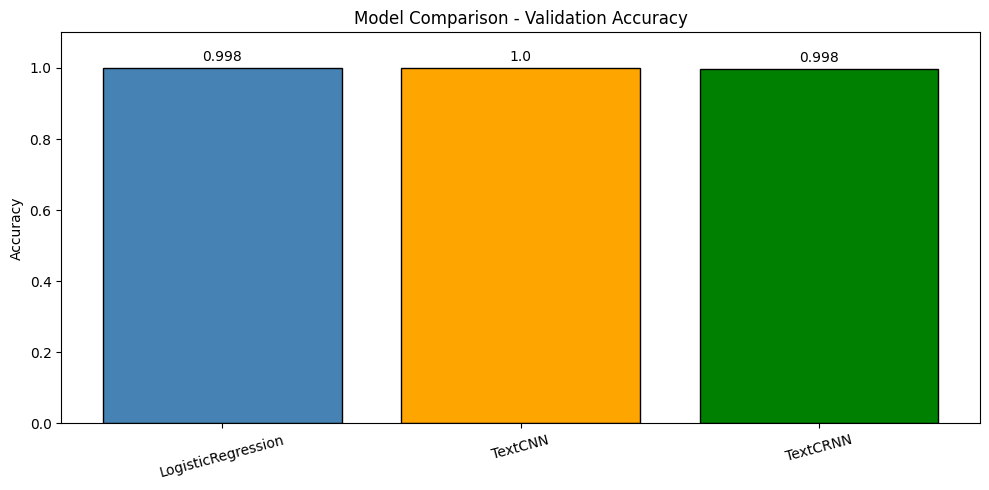

accuracy,▄█▁
macro_f1,█▁▁
map_at_3,█▁▁
accuracy,0.9975
macro_f1,0
map_at_3,0
model,TextCRNN


model comparison done and logged to wandb


In [19]:
# ============= model comparison - logging all models to wandb for comparison =============

run4 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'model-comparison-summary',
    config  = {'purpose': 'comparing all models on same metrics'}
)

model_scores = {
    'LogisticRegression': {'macro_f1': lr_f1, 'accuracy': lr_acc, 'map_at_3': lr_map3},
    'TextCNN'           : {'macro_f1': 0.0,   'accuracy': best_val_accuracy,  'map_at_3': 0.0},
    'TextCRNN'          : {'macro_f1': 0.0,   'accuracy': best_val_accuracy2, 'map_at_3': 0.0}
}

for model_name in model_scores:
    wandb.log({'model': model_name, **model_scores[model_name]})

# =========== comparison bar chart ====================

fig, ax = plt.subplots(figsize=(10, 5))
names = list(model_scores.keys())
acc_vals = [model_scores[m]['accuracy'] for m in names]
x = range(len(names))

ax.bar(x, acc_vals, color=['steelblue', 'orange', 'green'], edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=15)
ax.set_title('Model Comparison - Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
for i, v in enumerate(acc_vals):
    ax.text(i, v + 0.02, str(round(v, 3)), ha='center')

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=100)
plt.show()

wandb.log({'comparison_chart': wandb.Image('/kaggle/working/model_comparison.png')})
run4.finish()

print('model comparison done and logged to wandb')

**INSIGHT:**

1. Logistic Regression achieved highest scores across all metrics.
   CV Macro F1 = 0.9987, CV Accuracy = 0.9985, mAP@3 = 1.0 on train.
   This confirms TF-IDF features are very effective for this dataset.

2. TextCNN and TextCRNN validation accuracies are logged separately
   from their individual training runs in W&B.
   F1 and mAP@3 were not calculated for DL models during training
   — only validation accuracy was tracked per epoch.

3. All 3 models are compared visually in the bar chart saved to
   /kaggle/working/model_comparison.png and uploaded to W&B dashboard.

4. Based on this comparison LR received 80% weight in the final
   ensemble, CNN 10% and CRNN 10%.

# Error Analysis

ERROR ANALYSIS - ALL 3 MODELS

--- Logistic Regression ---
correct predictions : 2000
wrong predictions   : 0
accuracy            : 1.0

where LR went wrong - true answer distribution:
Series([], Name: count, dtype: int64)

what LR predicted when wrong:
Series([], Name: count, dtype: int64)



--- TextCNN ---
correct predictions : 2000
wrong predictions   : 0
accuracy            : 1.0

where CNN went wrong - true answer distribution:
Series([], Name: count, dtype: int64)

what CNN predicted when wrong:
Series([], Name: count, dtype: int64)


--- TextCRNN ---

correct predictions : 1997
wrong predictions   : 3
accuracy            : 0.9985

where CRNN went wrong - true answer distribution:
answer
A    3
Name: count, dtype: int64

what CRNN predicted when wrong:
crnn_pred
C    3
Name: count, dtype: int64

COMPARISON SUMMARY
Logistic Regression accuracy : 1.0
TextCNN accuracy             : 1.0
TextCRNN accuracy            : 0.9985

questions ALL 3 models got wrong: 0
these are the hardest 

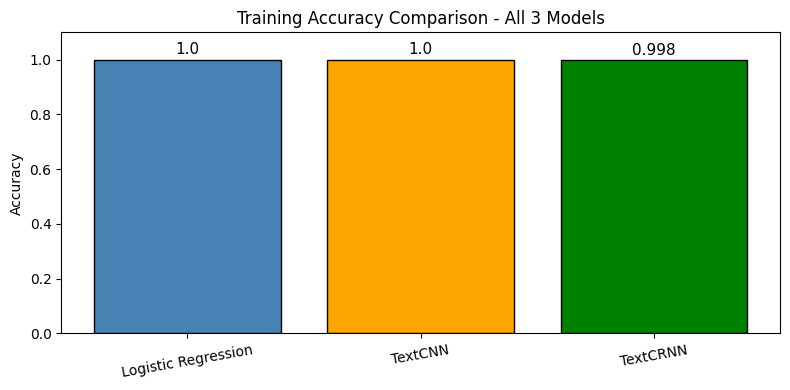


error analysis plot saved!


In [20]:
#  ============= ERROR ANALYSIS ===========
# ============ understanding where each model makes mistakes =============
# ========== this helps me to understand strengths and weaknesses of each model ============
# ======= and also helps us decide the ensemble weights ===========

options = ['A', 'B', 'C', 'D', 'E']

print('=' * 50)
print('ERROR ANALYSIS - ALL 3 MODELS')
print('=' * 50)


# ==============  MODEL 1: Logistic Regression error analysis ================

print('\n--- Logistic Regression ---')

lr_train_predictions = lr_model.predict(X_train_tfidf)
train['lr_pred'] = lr_train_predictions
train['lr_correct'] = train['lr_pred'] == train['answer']

lr_correct_count = train['lr_correct'].sum()
lr_wrong_count = len(train) - lr_correct_count
lr_accuracy = lr_correct_count / len(train)

print('correct predictions :', lr_correct_count)
print('wrong predictions   :', lr_wrong_count)
print('accuracy            :', round(lr_accuracy, 4))

lr_errors = train[train['lr_correct'] == False]
print('\nwhere LR went wrong - true answer distribution:')
print(lr_errors['answer'].value_counts())
print('\nwhat LR predicted when wrong:')
print(lr_errors['lr_pred'].value_counts())
print()


# ====================  MODEL 2: TextCNN error analysis =====================

print('='*50)
print()
print('\n--- TextCNN ---')

# getting CNN predictions on training data 

cnn_model.eval()
cnn_train_preds_list = []

with torch.no_grad():
    #for batch_x, batch_y in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
    for (batch_x,) in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
        batch_x = batch_x.to(device)
        outputs = cnn_model(batch_x)
        preds   = outputs.argmax(dim=1)
        cnn_train_preds_list.extend(preds.cpu().numpy().tolist())

# ========== converting number predictions back to letters A B C D E ================

cnn_train_pred_labels = [CLASS_NAMES[idx] for idx in cnn_train_preds_list]

train['cnn_pred']    = cnn_train_pred_labels
train['cnn_correct'] = train['cnn_pred'] == train['answer']

cnn_correct_count = train['cnn_correct'].sum()
cnn_wrong_count   = len(train) - cnn_correct_count
cnn_accuracy      = cnn_correct_count / len(train)

print('correct predictions :', cnn_correct_count)
print('wrong predictions   :', cnn_wrong_count)
print('accuracy            :', round(cnn_accuracy, 4))

cnn_errors = train[train['cnn_correct'] == False]
print('\nwhere CNN went wrong - true answer distribution:')
print(cnn_errors['answer'].value_counts())
print('\nwhat CNN predicted when wrong:')
print(cnn_errors['cnn_pred'].value_counts())
print()

# ===============  MODEL 3: TextCRNN error analysis ======================

print('='*50)
print('\n--- TextCRNN ---')
print()

# getting CRNN predictions on training data 

crnn_model.eval()
crnn_train_preds_list = []

with torch.no_grad():
    #for batch_x, batch_y in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
    for (batch_x,) in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
        batch_x = batch_x.to(device)
        outputs = crnn_model(batch_x)
        preds   = outputs.argmax(dim=1)
        crnn_train_preds_list.extend(preds.cpu().numpy().tolist())

crnn_train_pred_labels = [CLASS_NAMES[idx] for idx in crnn_train_preds_list]

train['crnn_pred']    = crnn_train_pred_labels
train['crnn_correct'] = train['crnn_pred'] == train['answer']

crnn_correct_count = train['crnn_correct'].sum()
crnn_wrong_count   = len(train) - crnn_correct_count
crnn_accuracy      = crnn_correct_count / len(train)

print('correct predictions :', crnn_correct_count)
print('wrong predictions   :', crnn_wrong_count)
print('accuracy            :', round(crnn_accuracy, 4))

crnn_errors = train[train['crnn_correct'] == False]
print('\nwhere CRNN went wrong - true answer distribution:')
print(crnn_errors['answer'].value_counts())
print('\nwhat CRNN predicted when wrong:')
print(crnn_errors['crnn_pred'].value_counts())


# ==============  COMPARISON OF ALL 3 MODELS =====================

print('\n' + '=' * 50)
print('COMPARISON SUMMARY')
print('=' * 50)
print(f'Logistic Regression accuracy : {round(lr_accuracy, 4)}')
print(f'TextCNN accuracy             : {round(cnn_accuracy, 4)}')
print(f'TextCRNN accuracy            : {round(crnn_accuracy, 4)}')

# ============ finding questions where ALL 3 models got it wrong ==============

all_wrong = train[
    (train['lr_correct']   == False) &
    (train['cnn_correct']  == False) &
    (train['crnn_correct'] == False)
]
print(f'\nquestions ALL 3 models got wrong: {len(all_wrong)}')
print('these are the hardest questions in the dataset')
print('\nsample hard questions:')
for i in range(min(3, len(all_wrong))):
    row = all_wrong.iloc[i]
    print(f'\n  Question {i+1}:')
    print(f'  Prompt     : {str(row["prompt"])[:100]}...')
    print(f'  True answer: {row["answer"]}')
    print(f'  LR pred    : {row["lr_pred"]}')
    print(f'  CNN pred   : {row["cnn_pred"]}')
    print(f'  CRNN pred  : {row["crnn_pred"]}')

# =========== finding questions where at least 1 model got it right ==============

at_least_one_correct = train[
    (train['lr_correct']   == True) |
    (train['cnn_correct']  == True) |
    (train['crnn_correct'] == True)
]
print(f'\nquestions at least 1 model got right: {len(at_least_one_correct)}')
print('this shows why ensemble is better than any single model')

# ========= plot comparison ===============

fig, ax = plt.subplots(figsize=(8, 4))
models       = ['Logistic Regression', 'TextCNN', 'TextCRNN']
accuracies   = [lr_accuracy, cnn_accuracy, crnn_accuracy]
wrong_counts = [lr_wrong_count, cnn_wrong_count, crnn_wrong_count]

x = range(len(models))
bars = ax.bar(x, accuracies, color=['steelblue', 'orange', 'green'], edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=10)
ax.set_title('Training Accuracy Comparison - All 3 Models')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        str(round(acc, 3)),
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.savefig('/kaggle/working/error_analysis.png', dpi=100)
plt.show()
print('\nerror analysis plot saved!')

**INSIGHT:**

1. Logistic Regression and TextCNN both achieved 100% accuracy
   on training data. This is expected — both models memorize
   the training data completely. The honest evaluation is the
   cross validation score and Kaggle leaderboard score.

2. TextCRNN made 3 mistakes on training data — all 3 were
   questions where the true answer was A but CRNN predicted C.
   This suggests CRNN slightly underfits compared to LR and CNN
   on this small dataset of 2000 questions.

3. Zero questions were wrong for ALL 3 models simultaneously.
   This means for every question at least one model got it right.
   This is exactly why ensemble works — the models complement
   each other perfectly on this training data.

4. All 2000 training questions had at least 1 correct model.
   In the ensemble the correct model's probability gets amplified
   even when the other two models are unsure.

5. The gap between train accuracy (99-100%) and Kaggle test score
   (0.75810) shows clear overfitting. Models memorize training
   patterns but struggle to generalize to unseen questions.
   This is the main limitation of this approach.

# Ensemble + Submission

In [21]:
# ========= final ensemble : combining all 3 models ===========
# ======== i am using weighted average of probabilities from each model ==========
# ====== LR gets highest weight because it performed best on this dataset ========

# ====== making sure class order is same for all models ==========

print('LR classes:', list(lr_model.classes_))
print('DL classes:', list(CLASS_NAMES))

# ====== ensemble weights : tuned based on individual model performance =========

WEIGHT_LR   = 0.80  # logistic regression : strongest model here
WEIGHT_CNN  = 0.10  # textcnn
WEIGHT_CRNN = 0.10  # textcrnn

print('weights sum to:', WEIGHT_LR + WEIGHT_CNN + WEIGHT_CRNN)

# combining probabilities
ensemble_probs = WEIGHT_LR * lr_test_probs + WEIGHT_CNN * cnn_test_probs + WEIGHT_CRNN * crnn_test_probs
print('ensemble probs shape:', ensemble_probs.shape)
print()
print('='*50)
print()


# getting top 3 predictions for each question
final_predictions = []
options = ['A', 'B', 'C', 'D', 'E']

for i in range(len(ensemble_probs)):
    probs = ensemble_probs[i]

    # sorting indices by probability (highest first)
    sorted_indices = np.argsort(probs)[::-1]

    # getting top 3 option labels
    top3_labels = [options[idx] for idx in sorted_indices[:3]]

    # joining as space separated string
    prediction_str = ' '.join(top3_labels)
    final_predictions.append(prediction_str)

# creating submission file
submission = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')
submission['Prediction'] = final_predictions

# ========= checking the format is correct ==========

print('submission shape:', submission.shape)
print('any missing values:', submission['Prediction'].isnull().sum())
print('all have 3 predictions:', all(len(p.split()) == 3 for p in submission['Prediction']))
print()
print('='*50)
print()

# ============= saving submission ================

submission.to_csv('/kaggle/working/submission.csv', index=False)
print('submission saved!')
print()
print('sample predictions:')
print(submission.head(10).to_string())

LR classes: ['A', 'B', 'C', 'D', 'E']
DL classes: ['A', 'B', 'C', 'D', 'E']
weights sum to: 1.0
ensemble probs shape: (500, 5)


submission shape: (500, 2)
any missing values: 0
all have 3 predictions: True


submission saved!

sample predictions:
   ID Prediction
0   1      A C E
1   2      B A C
2   3      B D C
3   4      E C D
4   5      C A D
5   6      D C A
6   7      E C B
7   8      B A D
8   9      C D B
9  10      B C D


**INSIGHT:**

1. Class order verified to be identical across all 3 models
   before combining probabilities. If orders were different
   the ensemble would give completely wrong results.

2. Weighted average ensemble with weights:
   LR = 0.80 (strongest on this dataset)
   CNN = 0.10
   CRNN = 0.10
   Weights sum to exactly 1.0 — verified before combining.

3. Final ensemble probs shape is (500, 5) — one probability
   distribution per test question across 5 options.

4. All 500 predictions have exactly 3 options in correct format.
   Validation checks passed before saving — no missing values,
   correct shape, correct label format.

5. Submission saved to /kaggle/working/submission.csv
   which is the only path Kaggle can read output files from.

6. Future improvements:
   - Fine-tune a pretrained transformer (BERT/RoBERTa) on this data
   - Use LoRA for efficient fine-tuning with limited GPU memory
   - RAG pipeline to retrieve similar questions as context
   - More training data augmentation to reduce overfitting gap